# Notebook 00 — Pre-Study Primer

**Read this before opening any other notebook.** This is the whole COMP11212 Part 2 course
in one continuous Python story, with the formal notation rendered next to the Python so
you can see they are the same idea in two scripts.

## The course in one sentence

> We will build a tiny language, ask **how long** it runs, prove it runs **correctly**,
> ask **what it can decide**, **encode** it as a number, then describe its meaning **two ways**.

That is the whole arc. Six chapters, six questions. Everything else is mechanism.

## How to read this

1. Top to bottom, no skipping. Each section ends with a one-line bridge to the formal notebook
   that develops the idea further.
2. Whenever you see a two-column box, **the right column is the same thing as the left column**
   — just written for a maths-flavoured machine. Squint at both. They mean the same thing.
3. Four cells along the way ask you to **predict** before reading the answer. Those cells matter
   the most. Take 30 seconds and write your guess on paper before scrolling.
4. ~35 cells, ~60–90 minutes. There are no exercises here. Once you finish, open
   `01_interpreter.ipynb` and start the formal pass.

*Estimated read time: 60–90 minutes.*


In [1]:
# Setup — imports + the two helpers we use throughout this notebook.
import sys
from pathlib import Path

# Make this work whether jupyter was started from notebooks/ or the repo root.
for candidate in [Path.cwd(), Path.cwd() / 'notebooks', Path.cwd().parent / 'notebooks']:
    if (candidate / 'while_lang.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise ImportError('could not find while_lang.py — start jupyter from the repo root or notebooks/')

from while_lang import (
    parse, run, trace, step,
    Config, Skip,
    A, B,
    count_steps, step_growth,
    verify_triple,
    big_step,
    encode_int, decode_int,
    encode_pair, decode_pair,
    encode_stmt, decode_stmt,
    stmt_to_str, state_to_str, cfg_to_str,
)

from IPython.display import HTML, display, Markdown
import html as _html_lib

def render_pair(python_code, formal_text, caption=''):
    # Side-by-side: Python on the LEFT, formal notation on the RIGHT.
    # Both panes use plain text in <pre>, so this works in Jupyter, GitHub,
    # nbviewer, and `nbconvert --execute`.
    py = _html_lib.escape(python_code)
    fm = _html_lib.escape(formal_text)
    cell_css = ('border: 1px solid currentColor; padding: 12px; '
                'vertical-align: top; width: 50%;')
    pre_py = ('margin: 0; font-family: Consolas, "DejaVu Sans Mono", monospace; '
              'font-size: 13px; white-space: pre-wrap; line-height: 1.4;')
    pre_fm = ('margin: 0; font-family: "Cambria Math", "STIX Two Math", '
              '"Latin Modern Math", Georgia, serif; font-size: 14px; '
              'white-space: pre-wrap; line-height: 1.5;')
    cap_html = ''
    if caption:
        cap_html = (
            f'<tr><td colspan="2" style="border: 1px solid currentColor; '
            f'padding: 8px; font-style: italic; opacity: 0.85;">'
            f'{_html_lib.escape(caption)}</td></tr>'
        )
    table = (
        '<table style="border-collapse: collapse; margin: 10px 0; width: 100%;">'
        '<tr>'
        f'<th style="{cell_css} text-align: center; font-weight: 600;">Python</th>'
        f'<th style="{cell_css} text-align: center; font-weight: 600;">Formal</th>'
        '</tr>'
        '<tr>'
        f'<td style="{cell_css}"><pre style="{pre_py}">{py}</pre></td>'
        f'<td style="{cell_css}"><pre style="{pre_fm}">{fm}</pre></td>'
        '</tr>'
        f'{cap_html}'
        '</table>'
    )
    display(HTML(table))

def trace_formal(prog, state=None, max_steps=80):
    # Programmatic formal trace — generated from while_lang's `trace()`,
    # not hand-typed. The right pane of every side-by-side cell comes from here.
    return trace(prog, state or {}, view='formal', max_steps=max_steps)

print('imports OK · helpers ready')


imports OK · helpers ready


In [2]:
# A 6-line Python program that sums 1..n. You've written something like this.
n = 10
result = 0
i = 1
while i <= n:
    result = result + i
    i = i + 1
print(f'sum 1..{n} = {result}')


sum 1..10 = 55


## Chapter 1 — A language that runs

We just ran a Python `while` loop. The course will run **the same loop**, but written for a
tiny imperative language called **While**, which exists for one reason: it is small enough
that we can prove things about it.

Same algorithm. Same result. The difference is the *machine reading it*: Python tells us
*what happened*, While lets us **prove** what *must* happen.

The new piece of vocabulary you'll meet here is **σ** (sigma). σ is just the Greek letter
for *state*: a dictionary mapping variable names to their current integer values. When the
textbook writes σ, you read "the dict".


In [3]:
# The same program, written in the While language and parsed by while_lang.py.
sum_prog = '''
    result := 0;
    i := 1;
    while i <= n do (
        result := result + i;
        i := i + 1
    )
'''

ast = parse(sum_prog)
print('parsed AST (pretty-printed):')
print(' ', stmt_to_str(ast))
print()
print('run on n=10:')
print(' ', run(sum_prog, {'n': 10}))


parsed AST (pretty-printed):
  result := 0; i := 1; while i ≤ n do (result := result + i; i := i + 1)

run on n=10:
  {'n': 10, 'result': 55, 'i': 11}


In [4]:
# Look closely: the Python loop and the While loop describe the same algorithm.
# The only differences are surface syntax (:= instead of =, do(...) instead of :,
# an explicit `while ... do` keyword). Everything else is identical.
#
# σ is just a Python dict. Two notations, same operation:
render_pair(
    python_code=(
        "sigma = {'n': 10}\n"
        "sigma['x'] = 5    # set a variable\n"
        "print(sigma)\n"
        "# {'n': 10, 'x': 5}"
    ),
    formal_text=(
        'σ = {n ↦ 10}\n'
        'σ[x ↦ 5]    -- update notation\n'
        '⟹  σ\' = {n ↦ 10, x ↦ 5}'
    ),
    caption='Same operation, two scripts. "σ[x ↦ 5]" is just "σ with x set to 5."'
)


**Bridge to the formal course:** Chapter 1 spends ~10 pages building this idea up. Notebook
`01_interpreter.ipynb` walks the syntax precisely; `02_syntax.ipynb` covers BNF and parsing.

But the punchline is on the slide above — *σ is a dict, := is assignment, and While is just
Python with a paranoid cousin doing the typing*.


## Chapter 2 — Small-step semantics

Question: how do we **define** what running a program means, formally enough that we can prove things?

The answer is the **small-step rule**: a precise description of what changes after **one** transition.
If we know how one step works, we know how the whole program runs — because *running* is just
*take a step, repeat until done*.


In [5]:
# Pretend while_lang.py doesn't exist. Here is small-step semantics in 12 lines
# of pure Python. This is exactly what the formal rules in chapter 2 say.

def python_step(prog, sigma):
    # One small step: returns (new_prog, new_sigma).
    # Each branch is one small-step rule from the chapter.
    op, *args = prog
    if op == ':=':                                       # assignment rule
        var, expr_value = args
        return ('skip',), {**sigma, var: expr_value(sigma)}
    if op == ';':                                        # sequence: step the first
        first, second = args
        if first == ('skip',):                           # skip; T  ⇒  T
            return second, sigma
        new_first, new_sigma = python_step(first, sigma)
        return (';', new_first, second), new_sigma
    if op == 'if':                                       # branch on condition
        cond, then_b, else_b = args
        return (then_b if cond(sigma) else else_b), sigma
    if op == 'while':                                    # unfold once
        cond, body = args
        if cond(sigma):
            return (';', body, ('while', cond, body)), sigma
        return ('skip',), sigma
    raise ValueError(op)

# Run a tiny program four steps.
prog = (';', (':=', 'x', lambda s: 1), (':=', 'y', lambda s: s['x'] + 2))
sigma = {}
print('starting:', sigma)
for step_n in range(4):
    if prog == ('skip',):
        print(f'after step {step_n}: done.')
        break
    prog, sigma = python_step(prog, sigma)
    print(f'after step {step_n+1}: {sigma}')


starting: {}
after step 1: {'x': 1}
after step 2: {'x': 1}
after step 3: {'x': 1, 'y': 3}
after step 3: done.


In [6]:
# Side-by-side: same program, two scripts. The formal pane is generated
# programmatically — we did NOT hand-type it. That 12-line python_step IS
# chapter 2's rule table; the lecture notes just write each branch as an
# inference rule instead of an `if`.
demo_prog = 'x := 1; y := x + 2'

py_text = (
    '# 12-line python_step output:\n'
    'starting: {}\n'
    "after step 1: {'x': 1}\n"
    "after step 2: {'x': 1}     # the 'skip; T  ⇒  T' rule\n"
    "after step 3: {'x': 1, 'y': 3}"
)

render_pair(
    python_code=py_text,
    formal_text=trace_formal(demo_prog, {}),
    caption='Left: my 12-line python_step. Right: trace() from while_lang.py — same trace, formal notation.',
)


### Click-through stepper (chapter 2 in one widget)

The interactive cell below lets you **drive the small-step machine yourself**. Each click
of *Next step* applies one rule; the right pane shows the formal `⟨S, σ⟩ ⇒ ⟨S', σ'⟩` exactly
as the textbook would write it.

*If the widget doesn't render (e.g. on GitHub), the static fallback below shows the first 8 steps.*


In [7]:
# Interactive small-step stepper. Two panes, lockstep.
# A static walkthrough of the first 8 steps is printed below the widget so this
# cell still works in environments where ipywidgets do not render (GitHub, nbviewer).
import ipywidgets as widgets
from itertools import islice
from while_lang import step_iter

STEPPER_PROG = '''
    i := 1;
    total := 0;
    while i <= 3 do (
        total := total + i;
        i := i + 1
    )
'''
STEPPER_INIT = {}

def make_stepper(source, init):
    parsed = parse(source)
    history = [Config(parsed, dict(init))]
    rules = []

    out = widgets.Output(layout=widgets.Layout(min_height='220px'))
    btn_step = widgets.Button(description='▶ Next step', button_style='primary')
    btn_reset = widgets.Button(description='↺ Reset')
    label = widgets.HTML(f'<b>Program:</b> <code>{stmt_to_str(parsed)}</code>')

    def render():
        out.clear_output(wait=True)
        with out:
            py_lines = ['# state (the python dict):',
                        repr(history[-1].state),
                        '',
                        '# remaining program:',
                        stmt_to_str(history[-1].stmt)]
            py_text = '\n'.join(py_lines)

            fm_lines = [cfg_to_str(history[0])]
            for j, r in enumerate(rules):
                fm_lines.append(f'  ⇒  {cfg_to_str(history[j+1])}    [{r}]')
            if isinstance(history[-1].stmt, Skip) and len(history) > 1:
                fm_lines.append('(done — left side is `skip`)')
            fm_text = '\n'.join(fm_lines)

            render_pair(py_text, fm_text)

    def on_step(_):
        if isinstance(history[-1].stmt, Skip):
            return
        t = step(history[-1])
        if t is None:
            return
        history.append(t.after)
        rules.append(t.rule)
        render()

    def on_reset(_):
        history[:] = [Config(parsed, dict(init))]
        rules[:] = []
        render()

    btn_step.on_click(on_step)
    btn_reset.on_click(on_reset)
    render()
    display(label, widgets.HBox([btn_step, btn_reset]), out)

make_stepper(STEPPER_PROG, STEPPER_INIT)

# Static walkthrough — first 8 steps, side-by-side. Renders even without widget support.
display(HTML('<p style="margin-top: 18px;"><b>Static walkthrough</b> (first 8 steps): '
             '— this is what you see if you click "Next step" eight times.</p>'))

transitions = list(islice(step_iter(STEPPER_PROG, {}, max_steps=200), 8))
py_lines = ['# python state evolves:', f'  start:  {{}}']
for i, t in enumerate(transitions, 1):
    py_lines.append(f'  step {i}: {t.after.state}    # rule = {t.rule}')
py_text = '\n'.join(py_lines)
fm_text = trace_formal(STEPPER_PROG, {}, max_steps=8)
render_pair(py_text, fm_text, caption='First 8 small-step transitions of the loop above.')


HTML(value='<b>Program:</b> <code>i := 1; total := 0; while i ≤ 3 do (total := total + i; i := i + 1)</code>')

Output(layout=Layout(min_height='220px'))

**Bridge to the formal course:** Chapter 2 is exactly the rules table that powers `python_step`
and `step()` — formalised. Notebook `03_semantics.ipynb` walks each rule precisely. The cheatsheet
(`CHEATSHEET_SEMANTICS.md`) tabulates them.

**You now understand the central theorem of chapter 2 in one sentence:** running a program is
`step` applied repeatedly until you hit `skip`.


## Chapter 3 — Complexity (how long does it run?)

We have semantics that say *what* a program does. Now ask: *how much work* is that?

The course's answer: **count the steps** — but not all of them. Only assignments and boolean
checks. The administrative `;` and `skip-;` rules are bookkeeping, not work.


In [8]:
# count_steps does this for us. Run on the sum-1..n program for several n.
for n in [1, 2, 5, 10, 25, 50, 100]:
    s = count_steps(sum_prog, {'n': n})
    print(f'  n={n:4d}    steps={s:5d}    (≈ {s/max(n,1):.2f} × n)')


  n=   1    steps=    6    (≈ 6.00 × n)
  n=   2    steps=    9    (≈ 4.50 × n)
  n=   5    steps=   18    (≈ 3.60 × n)
  n=  10    steps=   33    (≈ 3.30 × n)
  n=  25    steps=   78    (≈ 3.12 × n)
  n=  50    steps=  153    (≈ 3.06 × n)
  n= 100    steps=  303    (≈ 3.03 × n)


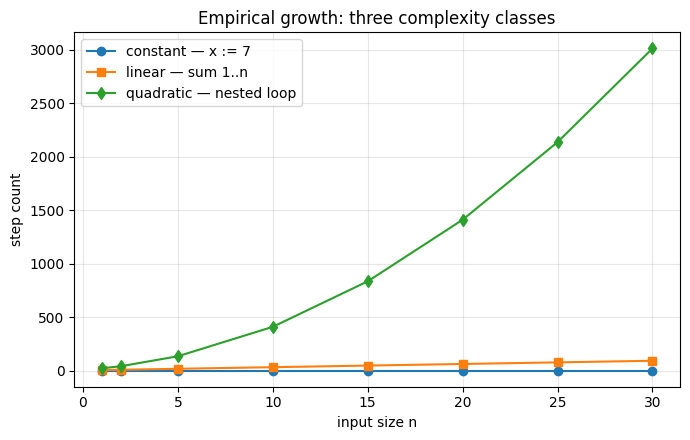

In [9]:
# Every doubling of n doubles the step count — the cost is LINEAR in n.
# Big-O captures exactly this: ignore the constant factor (~3.06 here),
# ignore small-input wobbles, just describe how cost grows.
# Three programs, three classes:
#   - constant: x := 7  (1 step regardless of n)
#   - linear:   sum 1..n
#   - quadratic: nested loop
import matplotlib.pyplot as plt

constant_prog = 'x := 7'   # one step regardless of input
linear_prog = sum_prog     # ~3n steps
quadratic_prog = '''
    total := 0;
    i := 0;
    while i <= n do (
        j := 0;
        while j <= n do (
            total := total + 1;
            j := j + 1
        );
        i := i + 1
    )
'''

sizes = [1, 2, 5, 10, 15, 20, 25, 30]
g_const = step_growth(constant_prog, lambda n: {}, sizes)
g_lin   = step_growth(linear_prog,  lambda n: {'n': n}, sizes)
g_quad  = step_growth(quadratic_prog, lambda n: {'n': n}, sizes)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sizes, [g_const[n] for n in sizes], 'o-', label='constant — x := 7')
ax.plot(sizes, [g_lin[n]   for n in sizes], 's-', label='linear — sum 1..n')
ax.plot(sizes, [g_quad[n]  for n in sizes], 'd-', label='quadratic — nested loop')
ax.set_xlabel('input size n')
ax.set_ylabel('step count')
ax.set_title('Empirical growth: three complexity classes')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Three lines, three growth rates: flat (constant), straight diagonal (linear), upward curve
(quadratic). The shape **is** the complexity class.

### 🔮 Predict cell #1

Before reading on, write your answer to this on paper:

> The program `while 0 <= x do (x := x - 2)`, started from `x = n`, runs how many steps?
> Linear, log, quadratic, or something else?

Run the cell below to reveal.


In [10]:
# Reveal — run after writing your prediction.
halve_prog = 'while 0 <= x do (x := x - 2)'
for n in [10, 100, 1000, 10_000]:
    print(f'  start x={n:>6d}    steps={count_steps(halve_prog, {"x": n}):>6d}')
print()
print('Answer: LINEAR. Each iteration drops x by 2, so total steps ≈ n/2 + 2.')
print('(Even though x decreases by a *factor*-like 2, it is a fixed *amount*-like 2,')
print(' so the program does a roughly constant amount of work per unit of input.)')
print()
print('Logarithmic would need x := x // 2 (integer divide) — a halving rule the')
print('While language does NOT have built-in. Languages without division stay linear.')


  start x=    10    steps=    13
  start x=   100    steps=   103
  start x=  1000    steps=  1003
  start x= 10000    steps= 10003

Answer: LINEAR. Each iteration drops x by 2, so total steps ≈ n/2 + 2.
(Even though x decreases by a *factor*-like 2, it is a fixed *amount*-like 2,
 so the program does a roughly constant amount of work per unit of input.)

Logarithmic would need x := x // 2 (integer divide) — a halving rule the
While language does NOT have built-in. Languages without division stay linear.


In [11]:
# Side-by-side: what big-O actually says.
# Big-O is a bound. count_steps gives the actual count; O(n) is the *family*.
render_pair(
    python_code=(
        '# we measured:\n'
        'count_steps(sum_prog, {"n":   1}) =      6\n'
        'count_steps(sum_prog, {"n":  10}) =     33\n'
        'count_steps(sum_prog, {"n": 100}) =    303\n'
        '# ratio steps / n converges to 3 as n grows.'
    ),
    formal_text=(
        'T(n) ≈ 3n + 3   ← step-count formula (chapter §3.1.4 style)\n'
        '\n'
        'T(n) ∈ O(n)  iff  ∃ c, n₀.  T(n) ≤ c·n  for all n ≥ n₀\n'
        '       (here: c = 4, n₀ = 3 works.)\n'
        '\n'
        'So: "sum is linear" formally means T ∈ O(n).'
    ),
    caption='Left: empirical counts. Right: the formal definition of T(n) ∈ O(n).'
)


**Bridge to the formal course:** Chapter 3 builds this rigorously. Notebooks `06_counting_steps.ipynb`
and `07_big_o.ipynb` work through the proofs; `CHEATSHEET_COMPLEXITY.md` collects the rules.


## Chapter 4 — Correctness (Hoare logic)

We can run a program once. We can count its steps. But the **important** question is:

> Will it produce the right answer **every** time, for every valid input?

Running it once is anecdote. Hoare logic gives proof. The basic shape:

$$\{P\}\;S\;\{Q\}$$

*"If `P` is true before, and `S` runs, then `Q` is true after."*  `P` is the **precondition**,
`Q` the **postcondition**, `S` the program.


In [12]:
# Empirical sanity check: does the sum program satisfy
#    {n ≥ 0}  sum_prog  {result = n(n+1)/2} ?
import random
random.seed(0)
samples = [{'n': random.randint(0, 50)} for _ in range(40)]

report = verify_triple(
    precond=lambda s: s.get('n', 0) >= 0,
    prog=sum_prog,
    postcond=lambda s: s.get('result', 0) == s['n'] * (s['n'] + 1) // 2,
    sample_states=samples,
)
print(f'sampled : {report["sampled"]}')
print(f'P held  : {report["precondition_holds"]}')
print(f'verified: {report["verified"]}')
print(f'failed  : {len(report["failed"])}')
print()
print('40/40 samples respect the triple. Encouraging — but a proof needs more.')


sampled : 40
P held  : 40
verified: 40
failed  : 0

40/40 samples respect the triple. Encouraging — but a proof needs more.


### 🔮 Predict cell #2

What property is **always** true between iterations of the loop in `sum_prog`? In other words —
what equation, involving `result`, `i`, and `n`, holds at the **top** of every iteration?

Write your guess on paper before scrolling. Hint: it's a partial sum.


In [13]:
# Reveal — run after writing your prediction.

# The loop invariant we'll claim:
#    result = i(i-1)/2     (so 'result is the sum so far, of 1..(i-1)')
# Plus the bookkeeping:  1 ≤ i ≤ n+1

print('Loop invariant:  result = i·(i-1)/2  AND  1 ≤ i ≤ n+1')
print()
print('At termination, the loop guard fails: i > n  ⇒  i = n+1.')
print('Substitute:  result = (n+1)·n/2 = n(n+1)/2.   ← This IS the postcondition.')
print()
print('So the proof rule for while-loops gives us:')
print('  {result = i(i-1)/2 ∧ 1 ≤ i ≤ n+1 ∧ ¬(i ≤ n)}  i.e.  {result = n(n+1)/2}.')
print()
print('That is the entire essence of Hoare logic: pick the right invariant,')
print('the proof writes itself.')


Loop invariant:  result = i·(i-1)/2  AND  1 ≤ i ≤ n+1

At termination, the loop guard fails: i > n  ⇒  i = n+1.
Substitute:  result = (n+1)·n/2 = n(n+1)/2.   ← This IS the postcondition.

So the proof rule for while-loops gives us:
  {result = i(i-1)/2 ∧ 1 ≤ i ≤ n+1 ∧ ¬(i ≤ n)}  i.e.  {result = n(n+1)/2}.

That is the entire essence of Hoare logic: pick the right invariant,
the proof writes itself.


In [14]:
# Side-by-side — Python assertion vs Hoare assertion. Same claim, two scripts.
render_pair(
    python_code=(
        '# inside a python while-loop, you might write:\n'
        'i = 1\n'
        'result = 0\n'
        'while i <= n:\n'
        '    assert result == i*(i-1)//2 and 1 <= i <= n+1\n'
        '    result = result + i\n'
        '    i = i + 1\n'
        '# after the loop:\n'
        'assert result == n*(n+1)//2'
    ),
    formal_text=(
        '{ n ≥ 0 }                     ← precondition P\n'
        '  result := 0; i := 1;\n'
        '  while i ≤ n do (\n'
        '    { result = i(i-1)/2 ∧ 1 ≤ i ≤ n+1 }   ← invariant I\n'
        '    result := result + i;\n'
        '    i := i + 1\n'
        '  )\n'
        '{ result = n(n+1)/2 }         ← postcondition Q'
    ),
    caption='`assert` in Python = `{...}` annotation in Hoare logic. Same idea.'
)


### Total correctness — does it actually finish?

Hoare's `{P} S {Q}` is **partial** correctness — *"if S terminates, Q holds."* To say it always
finishes, we add a **variant**: a non-negative integer expression that strictly decreases each
iteration. For the sum loop, the variant is `n - i + 1` (decreases by 1 every iteration, hits 0
when the loop quits).

**Bridge to the formal course:** Chapter 4 builds the inference rules. Notebook `09_hoare_partial.ipynb`
covers partial correctness; `10_hoare_total.ipynb` covers total. `CHEATSHEET_HOARE.md` is the tactical reference.


## Chapter 5 — Computability (what can be decided?)

Up to here, every question we asked **had** a procedure that answered it. Chapter 5 turns the
question on itself: are there questions that *no* program can answer?

Headline answer: **yes**. The most famous example is the **halting problem** — *given a program
and an input, does it halt?* — and we'll see in 5 lines of Python why no Python function can solve it.


In [15]:
# Suppose we had a magical halts() function. What goes wrong?

# def halts(prog, input):
#     '''Return True iff prog(input) terminates. (Imaginary — does NOT exist.)'''
#     ???

# We can write `halts` for SOME programs by hand:
def halts_for_obvious_cases(source_code: str, the_input: int):
    if source_code == 'return 7':                       return True
    if source_code == 'while True: pass':               return False
    if source_code == 'return n + 1' and the_input < 1_000_000: return True
    return None  # I don't know — would need to run it.

for src, inp in [('return 7', 0), ('while True: pass', 0), ('return n + 1', 5)]:
    print(f'halts({src!r:25s}, {inp}) = {halts_for_obvious_cases(src, inp)}')

print()
print('Easy cases: easy. Hard cases (arbitrary code): is halts() *always* decidable?')


halts('return 7'               , 0) = True
halts('while True: pass'       , 0) = False
halts('return n + 1'           , 5) = True

Easy cases: easy. Hard cases (arbitrary code): is halts() *always* decidable?


### 🔮 Predict cell #3

Suppose someone gave you a perfect, real `halts(prog, input)` function. We'll use it to construct
this odd little program:

```python
def paradox(p):
    if halts(p, p):
        while True:
            pass            # loop forever
    else:
        return              # halt
```

Now the question: **does `paradox(paradox)` halt?**

Write your answer (yes / no / can't tell) on paper. Then think about why. Then run the cell below.


In [16]:
# Reveal.
print('Case 1: assume paradox(paradox) DOES halt.')
print('  Then halts(paradox, paradox) returned True.')
print('  But by the code, that means we entered the `while True` branch.')
print('  So paradox(paradox) does NOT halt. CONTRADICTION.')
print()
print('Case 2: assume paradox(paradox) does NOT halt.')
print('  Then halts(paradox, paradox) returned False.')
print('  But by the code, that means we entered the `else: return` branch.')
print('  So paradox(paradox) DOES halt. CONTRADICTION.')
print()
print('Both branches contradict. The only way out is:')
print("  -- halts(p, x) cannot exist as a total computable function.")
print()
print('That is the halting problem. Found by Turing in 1936.')
print('It uses *exactly* the same self-reference trick as Cantor`s diagonal —')
print('we will see that next.')


Case 1: assume paradox(paradox) DOES halt.
  Then halts(paradox, paradox) returned True.
  But by the code, that means we entered the `while True` branch.
  So paradox(paradox) does NOT halt. CONTRADICTION.

Case 2: assume paradox(paradox) does NOT halt.
  Then halts(paradox, paradox) returned False.
  But by the code, that means we entered the `else: return` branch.
  So paradox(paradox) DOES halt. CONTRADICTION.

Both branches contradict. The only way out is:
  -- halts(p, x) cannot exist as a total computable function.

That is the halting problem. Found by Turing in 1936.
It uses *exactly* the same self-reference trick as Cantor`s diagonal —
we will see that next.


In [17]:
# Cantor's diagonal in 5 lines: there are more functions than programs.
# (The full argument is in chapter 5; this is the cartoon.)

# Imagine all programs that compute functions ℕ → {0, 1}, listed P₀, P₁, P₂, ...
# (Programs are finite strings, so they're countable: we CAN list them.)
# Run each program on each input and tabulate:
fake_programs = [
    lambda n: 0,                 # P₀: always 0
    lambda n: 1,                 # P₁: always 1
    lambda n: n % 2,             # P₂: parity
    lambda n: 1 if n < 3 else 0, # P₃
    lambda n: (n // 2) % 2,      # P₄
]

table = [[p(n) for n in range(5)] for p in fake_programs]
for i, row in enumerate(table):
    diagonal_marker = ['↓' if j == i else ' ' for j in range(5)]
    print(f'  P{i}:  ' + '  '.join(f'{v}{m}' for v, m in zip(row, diagonal_marker)))
print()

# Build a function that DISAGREES with each P_i on input i:
diagonal = [1 - table[i][i] for i in range(5)]
print(f'  D :  ' + '  '.join(f'{v} ' for v in diagonal) + '   (D(i) = 1 - P_i(i))')
print()
print('D differs from P_i at position i — for every i.')
print('So D is not in our list. But our list contained EVERY program.')
print('Therefore D is a function ℕ → {0,1} that no program computes.')
print()
print('Most functions are not computable. We just showed one.')


  P0:  0↓  0   0   0   0 
  P1:  1   1↓  1   1   1 
  P2:  0   1   0↓  1   0 
  P3:  1   1   1   0↓  0 
  P4:  0   0   1   1   0↓

  D :  1   0   1   1   1    (D(i) = 1 - P_i(i))

D differs from P_i at position i — for every i.
So D is not in our list. But our list contained EVERY program.
Therefore D is a function ℕ → {0,1} that no program computes.

Most functions are not computable. We just showed one.


**Bridge to the formal course:** Chapter 5 develops both arguments precisely. Notebook
`12_computability.ipynb` covers decidability; `13_halting_universality.ipynb` covers the halting
problem and the universal program ζ; `CHEATSHEET_COMPUTABILITY.md` has the diagonalisation recipes.


## Chapter 6 — Encodings (programs are numbers)

There's an obvious-looking observation hiding a *huge* idea:

> Programs are strings. Strings are numbers (write the bytes in binary). Therefore programs are numbers.

If programs are numbers, then a program can take **another program** as input — by taking its
number. That's how `paradox(paradox)` from chapter 5 even *makes sense*. It's also how we'll
write a single program that simulates **any** other program (the universal program ζ).

The course constructs explicit **Gödel encodings**: total injective functions that turn each
kind of object into a unique natural number.


In [18]:
# Three primitive encodings: integers, pairs, and statements.

print('encode_int — interleaves negatives and positives so we can encode ℤ in ℕ:')
for x in [0, 1, -1, 2, -2, 3, -3, 7, -7]:
    print(f'  encode_int({x:>3d}) = {encode_int(x):>3d}')
print()

print('encode_pair — Cantor pairing: every (m, n) pair gets a unique ℕ:')
for m, n in [(0,0), (0,1), (1,0), (1,1), (2,3), (3,2), (5,7)]:
    print(f'  encode_pair({m}, {n}) = {encode_pair(m, n):>5d}')


encode_int — interleaves negatives and positives so we can encode ℤ in ℕ:
  encode_int(  0) =   0
  encode_int(  1) =   2
  encode_int( -1) =   1
  encode_int(  2) =   4
  encode_int( -2) =   3
  encode_int(  3) =   6
  encode_int( -3) =   5
  encode_int(  7) =  14
  encode_int( -7) =  13

encode_pair — Cantor pairing: every (m, n) pair gets a unique ℕ:
  encode_pair(0, 0) =     0
  encode_pair(0, 1) =     2
  encode_pair(1, 0) =     1
  encode_pair(1, 1) =     5
  encode_pair(2, 3) =    27
  encode_pair(3, 2) =    39
  encode_pair(5, 7) =   479


In [19]:
# Now encode the WHOLE sum program as a single integer.
g = encode_stmt(parse(sum_prog))
print(f'sum_prog encoded as a Gödel number with {len(str(g))} digits.')
print()
print('First 80 digits:', str(g)[:80], '...')
print()
print("Yes, that's a SINGLE integer. The whole program: 6 lines of source code,")
print('compressed losslessly (almost — see predict #4 below) into one ℕ.')


sum_prog encoded as a Gödel number with 2883 digits.

First 80 digits: 37761227888760835522476687612637335261196303096135085375766452070655144480632408 ...

Yes, that's a SINGLE integer. The whole program: 6 lines of source code,
compressed losslessly (almost — see predict #4 below) into one ℕ.


### 🔮 Predict cell #4

If we **decode** that integer back into a program, will we get **exactly** the original
`sum_prog` source?

Yes / No / Almost?

Write your answer first. Then run the cell below.


In [20]:
# Reveal.
ast_original = parse(sum_prog)
g = encode_stmt(ast_original)
ast_roundtrip = decode_stmt(g)

print('original :', stmt_to_str(ast_original))
print('decoded  :', stmt_to_str(ast_roundtrip))
print()
print('ALMOST.  The structure is identical, but variable names get normalised')
print('to canonical x_0, x_1, ...  Why?  Because the encoding maps variables')
print('to integers (encode_var), and the original names are not recoverable')
print('from those integers — only their *order of first appearance*.')
print()
print('Bigger lesson: an encoding preserves what *matters* for the meaning of')
print('the program, not its surface text. The two programs above have')
print('identical small-step traces (modulo renaming).')


original : result := 0; i := 1; while i ≤ n do (result := result + i; i := i + 1)
decoded  : x_0 := 0; x_1 := 1; while x_1 ≤ x_2 do (x_0 := x_0 + x_1; x_1 := x_1 + 1)

ALMOST.  The structure is identical, but variable names get normalised
to canonical x_0, x_1, ...  Why?  Because the encoding maps variables
to integers (encode_var), and the original names are not recoverable
from those integers — only their *order of first appearance*.

Bigger lesson: an encoding preserves what *matters* for the meaning of
the program, not its surface text. The two programs above have
identical small-step traces (modulo renaming).


**Bridge to the formal course:** Chapter 6 builds the encodings explicitly: $\beta$ for integers,
$\varphi$ for pairs, $\psi$ for lists, $\varphi_S$ for statements. Notebook `15_encodings.ipynb`
walks each one; `CHEATSHEET_ENCODINGS.md` has all the formulas.

Once you have encodings, the universal program $\zeta$ (chapter 5) becomes possible: $\zeta$ takes
a program's number and an input, and simulates the program. Without encodings, $\zeta$ couldn't
even be stated.


## Appendix B — Big-step semantics (one last reframe)

Chapter 2 gave us **small-step**: every transition, one rule at a time. There is a second style:
**big-step** (also called *natural* or *evaluation* semantics):

$$\langle S, \sigma\rangle \Downarrow \sigma'$$

*"Run S in σ; you end in σ'."*  No intermediate trace. Just the answer.

Why have both? Different proofs are easier in different styles. Small-step is good for
**complexity** (you can count steps); big-step is good for **correctness** (you only argue about
the final state). Theorem 30 in the appendix proves they describe the same set of terminating programs.


In [21]:
# big_step gives you the final state directly. No trace, no rules to count.
final_bs = big_step(parse(sum_prog), {'n': 10})
print('big_step(sum_prog, {n: 10}):')
print(' ', final_bs)
print()
print('Compare to small-step:')
print(' ', run(sum_prog, {'n': 10}))
print()
print('Identical final state — Theorem 30 in action.')


big_step(sum_prog, {n: 10}):
  {'n': 10, 'result': 55, 'i': 11}

Compare to small-step:
  {'n': 10, 'result': 55, 'i': 11}

Identical final state — Theorem 30 in action.


In [22]:
# Side-by-side — small-step trace vs big-step single judgment.
small_trace = trace_formal('x := 2; y := x + 1', {})

py_text = (
    '# small-step: every transition shown\n'
    'sigma = {}\n'
    "sigma = {**sigma, 'x': 2}              # 1st step\n"
    '# (admin: skip; T  ⇒  T)               # 2nd step\n'
    "sigma = {**sigma, 'y': sigma['x'] + 1} # 3rd step\n"
    '\n'
    '# big-step: just the answer\n'
    'final = big_step(parse("x:=2; y:=x+1"), {})\n'
    "# final = {'x': 2, 'y': 3}"
)

formal_text = (
    small_trace +
    '\n\n———— big-step version ————\n'
    '⟨x := 2; y := x + 1, {}⟩  ⇓  {x ↦ 2, y ↦ 3}'
)

render_pair(py_text, formal_text,
            caption='Small-step is the trace. Big-step is the answer. Theorem 30: they agree.')


## You're done. Now what?

You've seen the whole arc:

| Chapter | The question | The answer (in Python) |
|:--|:--|:--|
| 1 — Syntax | What's a program? | An AST. (`parse(source)`) |
| 2 — Small-step | What does running mean? | Step until skip. (`step()`) |
| 3 — Complexity | How long does it take? | Count assignments + checks. (`count_steps`) |
| 4 — Hoare | Is it correct? | Pre/post-conditions. (`verify_triple`) |
| 5 — Computability | Can every question be answered? | No — diagonalisation. |
| 6 — Encodings | Are programs data? | Yes — Gödel numbers. (`encode_stmt`) |
| App B — Big-step | Trace or answer? | Both, equivalently. (`big_step`) |

**Next move:** open `01_interpreter.ipynb` and start the formal pass. Every idea from this
primer gets developed precisely there. The cheatsheets (`CHEATSHEET*.md`) are your tactical
reference — keep one open while you work through N1–N18.

If a formal proof feels alien, come back here. The Python is always a translation away.

*Welcome to COMP11212.*
